## Land Suitability

Great, we are now ready to perform our first LSA ! To do so, we use `LandSuitability` that allows to compute the overall suitability of several criteria and that has the following attributes:
- name: LSA name
- criteria: `dict` of `SuitabilityCriteria` (see suitability criteria [tutorial](criteria.ipynb))
- short_name (optional): LSA short name
- long_name (optional): LSA long name
- description (optional): LSA description

First we have to define the criteria. Here, we use three criteria: the potential rooting depth and water requirement already used above and a third one corresponding to the soil draingage class (discrete). We are going to split criteria in two categories, soil and climate, and change the weight of each of them.

In [ ]:
import matplotlib.pyplot as plt
from xclim.atmos import precip_accumulation

from lsapy import LandSuitability, SuitabilityCriteria, SuitabilityFunction
from lsapy.utils import load_climate_data, load_soil_data

soil_data = load_soil_data()
clim_data = load_climate_data().interp_like(
    soil_data, method="nearest"
)  # resample climate data to soil data resolution

ls = LandSuitability(
    name="first_lsa",
    long_name="My First Land Suitability Analysis",
    criteria={
        "potential_root_depth": SuitabilityCriteria(
            name="potential_root_depth",
            long_name="Potential Rooting Depth Suitability",
            weight=2,
            category="soil",
            indicator=soil_data["PRD"],  # indicator as xr.DataArray
            func=SuitabilityFunction(func_method="vetharaniam2022_eq5", func_params={"a": -11.98, "b": 0.459}),
        ),
        "drainage_class": SuitabilityCriteria(
            name="drainage_class",
            weight=1,
            category="soil",
            long_name="Drainage Class Suitability",
            indicator=soil_data["DRC"],
            func=SuitabilityFunction(
                func_method="discrete", func_params={"rules": {"1": 0, "2": 0.1, "3": 0.5, "4": 0.9, "5": 1}}
            ),
        ),
        "water_requirements": SuitabilityCriteria(
            name="water_requirements",
            weight=0.5,
            category="climate",
            long_name="Annual Rainfall Requirement Suitability",
            indicator=precip_accumulation(clim_data["pr"], freq="YS"),  # indicator as xr.DataArray
            func=SuitabilityFunction(func_method="vetharaniam2022_eq5", func_params={"a": 0.876, "b": 1248}),
        ),
    },
)

Then, we can compute the suitability starting with the criteria.

In [ ]:
ls.compute_criteria_suitability(inplace=True)
ls.data

Computing potential_root_depth...
Computing drainage_class...
Computing water_requirements...


<xarray.Dataset> Size: 922kB
Dimensions:               (lon: 100, lat: 100, time: 10)
Coordinates:
  * lon                   (lon) float64 800B 170.0 170.1 170.1 ... 174.9 175.0
  * lat                   (lat) float64 800B -43.98 -43.92 ... -39.08 -39.02
  * time                  (time) datetime64[ns] 80B 2000-01-01 ... 2009-01-01
Data variables:
    potential_root_depth  (lat, lon) float64 80kB 0.2833 0.2076 ... 0.9426
    drainage_class        (lat, lon) float32 40kB 1.0 nan 1.0 ... 1.0 1.0 0.9
    water_requirements    (time, lat, lon) float64 800kB nan nan nan ... nan nan
Attributes:
    name:       first_lsa
    criteria:   ['potential_root_depth', 'drainage_class', 'water_requirements']
    long_name:  My First Land Suitability Analysis

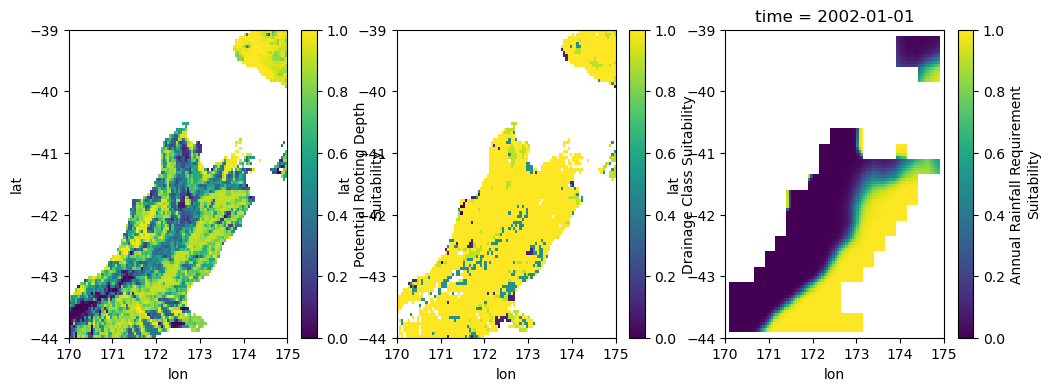

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ls.data["potential_root_depth"].plot(ax=ax[0], vmin=0, vmax=1)
ls.data["drainage_class"].plot(ax=ax[1], vmin=0, vmax=1)
ls.data["water_requirements"].isel(time=2).plot(ax=ax[2], vmin=0, vmax=1)
plt.show()

Now, we can compute the suitability of categories. There are several method implemanted to aggregate criteria (e.g., mean, weighted mean, geometric mean, weighted geometric mean, and limiting factor). Here, we are going to use a simple weighted mean.

In [ ]:
ls.compute_category_suitability(method="weighted_mean", keep_criteria=True, inplace=True)
ls.data

Computing soil...
Computing climate...


<xarray.Dataset> Size: 2MB
Dimensions:               (lon: 100, lat: 100, time: 10)
Coordinates:
  * lon                   (lon) float64 800B 170.0 170.1 170.1 ... 174.9 175.0
  * lat                   (lat) float64 800B -43.98 -43.92 ... -39.08 -39.02
  * time                  (time) datetime64[ns] 80B 2000-01-01 ... 2009-01-01
Data variables:
    potential_root_depth  (lat, lon) float64 80kB 0.2833 0.2076 ... 0.9426
    drainage_class        (lat, lon) float32 40kB 1.0 nan 1.0 ... 1.0 1.0 0.9
    water_requirements    (time, lat, lon) float64 800kB nan nan nan ... nan nan
    soil                  (lat, lon) float64 80kB 0.5222 nan ... 0.9593 0.9284
    climate               (time, lat, lon) float64 800kB nan nan nan ... nan nan
Attributes:
    name:       first_lsa
    criteria:   ['potential_root_depth', 'drainage_class', 'water_requirements']
    long_name:  My First Land Suitability Analysis

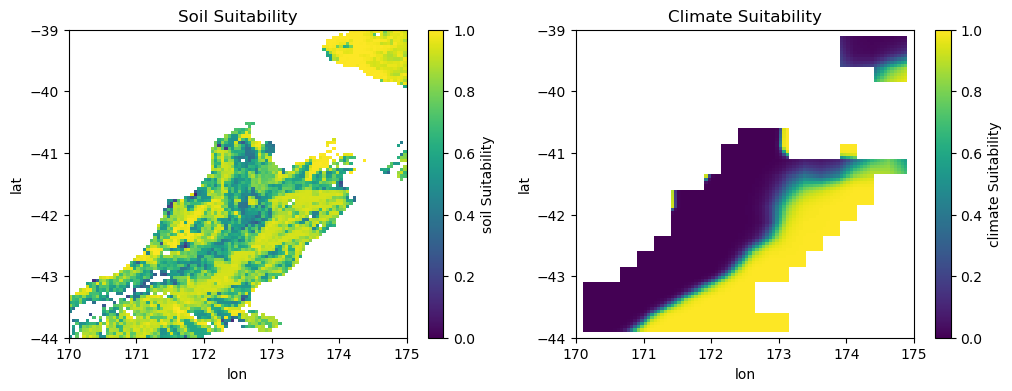

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ls.data["soil"].plot(ax=ax[0], vmin=0, vmax=1)
ax[0].set_title("Soil Suitability")
ls.data["climate"].isel(time=2).plot(ax=ax[1], vmin=0, vmax=1)
ax[1].set_title("Climate Suitability")
plt.show()

Finally, we can compute the overall suitability.

In [ ]:
ls.compute_suitability(method="weighted_mean", by_category=True, inplace=True, keep_all=True)
ls.data

Computing suitability...


<xarray.Dataset> Size: 3MB
Dimensions:               (lon: 100, lat: 100, time: 10)
Coordinates:
  * lon                   (lon) float64 800B 170.0 170.1 170.1 ... 174.9 175.0
  * lat                   (lat) float64 800B -43.98 -43.92 ... -39.08 -39.02
  * time                  (time) datetime64[ns] 80B 2000-01-01 ... 2009-01-01
Data variables:
    potential_root_depth  (lat, lon) float64 80kB 0.2833 0.2076 ... 0.9426
    drainage_class        (lat, lon) float32 40kB 1.0 nan 1.0 ... 1.0 1.0 0.9
    water_requirements    (time, lat, lon) float64 800kB nan nan nan ... nan nan
    soil                  (lat, lon) float64 80kB 0.5222 nan ... 0.9593 0.9284
    climate               (time, lat, lon) float64 800kB nan nan nan ... nan nan
    suitability           (lat, lon, time) float64 800kB nan nan nan ... nan nan
Attributes:
    name:       first_lsa
    criteria:   ['potential_root_depth', 'drainage_class', 'water_requirements']
    long_name:  My First Land Suitability Analysis

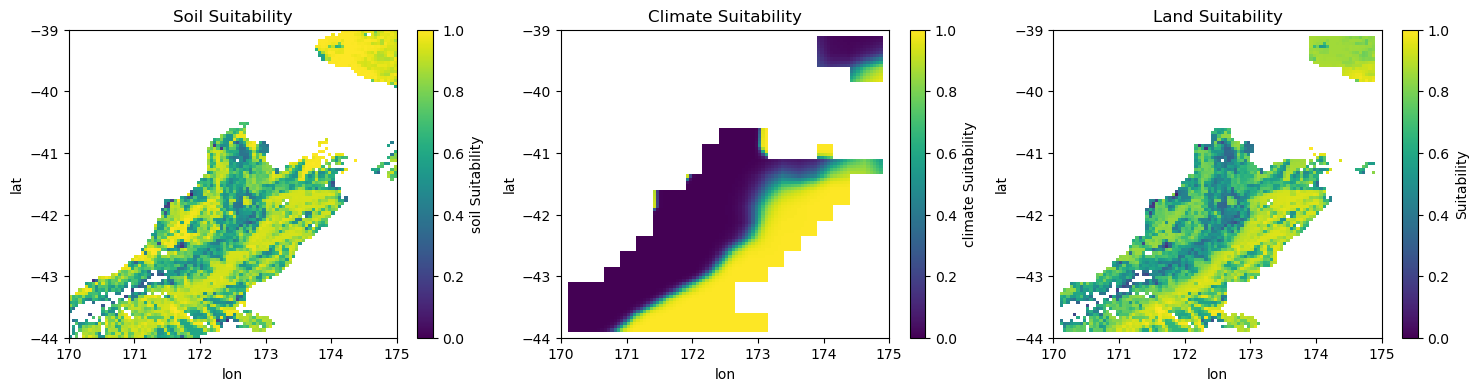

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ls.data["soil"].plot(ax=ax[0], vmin=0, vmax=1)
ax[0].set_title("Soil Suitability")
ls.data["climate"].isel(time=2).plot(ax=ax[1], vmin=0, vmax=1)
ax[1].set_title("Climate Suitability")
ls.data["suitability"].isel(time=2).plot(ax=ax[2], vmin=0, vmax=1)
ax[2].set_title("Land Suitability")
plt.show()